#   ApplyGriddedLapseRate算法验证
使用官方测试数据测试修改后的ApplyGriddedLapseRate算法。

## 环境准备

In [1]:
from pathlib import Path
import sys

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os

# 添加模块路径
PACKAGE_ROOT = Path.cwd().resolve().parents[0] #包根目录
PROJECT_ROOT = PACKAGE_ROOT.parent # 项目根目录
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from temperature.src.lapse_rate import (
    compute_lapse_rate_adjustment,
    ApplyGriddedLapseRate,
    DALR,
    ELR
)


plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题

print(f"干绝热递减率 (DALR): {DALR} K/m")
print(f"环境递减率 (ELR): {ELR} K/m")

d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


干绝热递减率 (DALR): -0.0098 K/m
环境递减率 (ELR): -0.0065 K/m


## 数据预处理

In [2]:
import warnings

from temperature.utils.utils import rebuild_to_meb_griddata

try:
    from pyproj import CRS, Transformer
except ImportError:
    CRS = None
    Transformer = None

_REQUIRED_DIMS = ("member", "level", "time", "dtime", "lat", "lon")
_DEFAULT_ATTRS = {
    "units": None,
    "model": None,
    "dtime_units": "hour",
    "level_type": "isobaric",
    "time_type": "UT",
    "time_bounds": [0, 0],
}


def _is_nearly_uniform_step(values: np.ndarray, rtol: float = 5e-3, atol: float = 1e-8) -> bool:
    arr = np.asarray(values, dtype=np.float64)
    if arr.ndim != 1 or arr.size < 3:
        return True
    diffs = np.diff(arr)
    if not np.all(np.isfinite(diffs)):
        return False
    return np.allclose(diffs, diffs[0], rtol=rtol, atol=atol)


def _fill_required_attrs(attrs: dict) -> dict:
    filled = dict(attrs)
    for key, default in _DEFAULT_ATTRS.items():
        if key not in filled or filled[key] in (None, ""):
            filled[key] = default
    return filled


def _find_grid_mapping_name(dataset: xr.Dataset, data: xr.DataArray) -> str | None:
    gm = data.attrs.get("grid_mapping")
    if isinstance(gm, str) and gm in dataset.variables:
        return gm
    for var_name in dataset.data_vars:
        cand = dataset[var_name].attrs.get("grid_mapping")
        if isinstance(cand, str) and cand in dataset.variables:
            return cand
    return None


def _build_transformer(dataset: xr.Dataset, data: xr.DataArray):
    if CRS is None or Transformer is None:
        warnings.warn("pyproj 不可用，跳过投影坐标转经纬度。")
        return None
    grid_mapping_name = _find_grid_mapping_name(dataset, data)
    if grid_mapping_name is None:
        return None
    attrs = dict(dataset[grid_mapping_name].attrs)
    try:
        if attrs.get("crs_wkt"):
            src_crs = CRS.from_wkt(attrs["crs_wkt"])
        else:
            src_crs = CRS.from_cf(attrs)
        return Transformer.from_crs(src_crs, CRS.from_epsg(4326), always_xy=True)
    except Exception as exc:
        warnings.warn(f"无法解析 grid_mapping={grid_mapping_name}，跳过坐标转换: {exc}")
        return None


def _convert_projection_to_latlon(data: xr.DataArray, dataset: xr.Dataset):
    dims = tuple(data.dims)
    if "projection_y_coordinate" not in dims or "projection_x_coordinate" not in dims:
        return data, False
    y_coord = data.coords.get("projection_y_coordinate")
    x_coord = data.coords.get("projection_x_coordinate")
    if y_coord is None or x_coord is None or y_coord.ndim != 1 or x_coord.ndim != 1:
        return data, False
    transformer = _build_transformer(dataset, data)
    if transformer is None:
        return data, False

    x_vals = np.asarray(x_coord.values, dtype=np.float64)
    y_vals = np.asarray(y_coord.values, dtype=np.float64)
    xx, yy = np.meshgrid(x_vals, y_vals)
    lon2d, lat2d = transformer.transform(xx, yy)
    lat_1d = np.nanmean(lat2d, axis=1)
    lon_1d = np.nanmean(lon2d, axis=0)

    out = data.rename({"projection_y_coordinate": "lat", "projection_x_coordinate": "lon"})
    out = out.assign_coords(lat=("lat", lat_1d.astype(np.float64)), lon=("lon", lon_1d.astype(np.float64)))

    if not (_is_nearly_uniform_step(lat_1d) and _is_nearly_uniform_step(lon_1d)):
        lat_lin = np.linspace(float(lat_1d[0]), float(lat_1d[-1]), lat_1d.size, dtype=np.float64)
        lon_lin = np.linspace(float(lon_1d[0]), float(lon_1d[-1]), lon_1d.size, dtype=np.float64)
        out = out.interp(lat=lat_lin, lon=lon_lin, method="linear")
        out = out.assign_coords(lat=("lat", lat_lin), lon=("lon", lon_lin))
        warnings.warn("投影转经纬度后坐标非等距，已重采样到规则经纬网。")

    out_attrs = dict(out.attrs)
    out_attrs.pop("grid_mapping", None)
    out.attrs = out_attrs
    return out, True


def _normalize_dims(data: xr.DataArray, dataset: xr.Dataset) -> xr.DataArray:
    data, _ = _convert_projection_to_latlon(data, dataset)
    dims = tuple(data.dims)

    rename_map = {}
    if "latitude" in dims and "lat" not in dims:
        rename_map["latitude"] = "lat"
    if "longitude" in dims and "lon" not in dims:
        rename_map["longitude"] = "lon"
    if "y" in dims and "lat" not in dims:
        rename_map["y"] = "lat"
    if "x" in dims and "lon" not in dims:
        rename_map["x"] = "lon"
    if rename_map:
        data = data.rename(rename_map)
        dims = tuple(data.dims)

    if data.ndim == 2:
        y_name = "lat" if "lat" in dims else dims[-2]
        x_name = "lon" if "lon" in dims else dims[-1]
        data = data.transpose(y_name, x_name)
        if y_name != "lat" or x_name != "lon":
            data = data.rename({y_name: "lat", x_name: "lon"})
    elif data.ndim == 3:
        level_name = "level" if "level" in dims else dims[0]
        y_name = "lat" if "lat" in dims else dims[-2]
        x_name = "lon" if "lon" in dims else dims[-1]
        data = data.transpose(level_name, y_name, x_name)
        rename_3d = {}
        if level_name != "level":
            rename_3d[level_name] = "level"
        if y_name != "lat":
            rename_3d[y_name] = "lat"
        if x_name != "lon":
            rename_3d[x_name] = "lon"
        if rename_3d:
            data = data.rename(rename_3d)
    elif data.ndim == 6 and set(dims) == set(_REQUIRED_DIMS):
        data = data.transpose(*_REQUIRED_DIMS)
    else:
        raise ValueError(f"暂不支持维度 {dims}（ndim={data.ndim}）。请先整理为 2D、3D 或标准 6D。")

    if "member" not in data.dims:
        data = data.expand_dims({"member": ["data0"]})
    if "level" not in data.dims:
        data = data.expand_dims({"level": [0.0]})
    if "time" not in data.dims:
        data = data.expand_dims({"time": [np.datetime64("1970-01-01T00:00:00")]})
    if "dtime" not in data.dims:
        data = data.expand_dims({"dtime": [0]})

    data = data.transpose(*_REQUIRED_DIMS)
    data.attrs = _fill_required_attrs(dict(data.attrs))
    return rebuild_to_meb_griddata(np.asarray(data.values, dtype=np.float32), data)


def preprocess_to_meb6d(src_path: Path, dst_path: Path, var_name: str) -> None:
    """将单个 nc 文件预处理为标准六维并写出。"""
    ds = xr.open_dataset(src_path, decode_timedelta=False)
    try:
        if var_name not in ds.data_vars:
            raise ValueError(f"变量 {var_name} 不存在，可选: {list(ds.data_vars)}")
        data = ds[var_name].copy()
        merged_attrs = dict(data.attrs)
        if merged_attrs.get("model") in (None, "") and "mosg__model_configuration" in ds.attrs:
            merged_attrs["model"] = ds.attrs.get("mosg__model_configuration")
        data.attrs = _fill_required_attrs(merged_attrs)

        normalized = _normalize_dims(data, ds).astype(np.float32, copy=False)
        normalized.name = var_name
        normalized.attrs = {key: ("" if value is None else value) for key, value in dict(normalized.attrs).items()}

        dst_path.parent.mkdir(parents=True, exist_ok=True)
        normalized.to_dataset(name=normalized.name).to_netcdf(dst_path)
    finally:
        ds.close()


In [3]:
# 预处理：升维为 meteva_base 标准六维（投影坐标转经纬度）
RUN_PREPROCESS = False  # 设为 True 时执行写出

input_dir = (Path.cwd() / "../test_data/apply_lapse_rate_data").resolve()
output_dir = input_dir / "normalized_meb6d"
output_dir.mkdir(parents=True, exist_ok=True)

jobs = [
    ("ukvx_temperature.nc", "air_temperature"),
    ("ukvx_lapse_rate.nc", "lapse_rate"),
    ("ukvx_orography.nc", "surface_altitude"),
    ("highres_orog.nc", "surface_altitude"),
    ("kgo.nc", "air_temperature"),
    ("original_algorithm_result.nc", "air_temperature"),
]

if RUN_PREPROCESS:
    for filename, var_name in jobs:
        in_file = input_dir / filename
        out_file = output_dir / filename
        print(f"正在处理: {filename}")
        preprocess_to_meb6d(in_file, out_file, var_name)
    print("预处理完成，输出目录:", output_dir)
else:
    print("跳过预处理（RUN_PREPROCESS=False），输出目录:", output_dir)

跳过预处理（RUN_PREPROCESS=False），输出目录: D:\workspace\improver\temperature\test_data\apply_lapse_rate_data\normalized_meb6d


## 读取输入数据

In [4]:
# 读取官方测试数据（优先使用 normalized_meb6d）
print("正在读取官方测试数据（优先 normalized_meb6d）...")

from pathlib import Path

apply_data_dir = Path('../test_data/apply_lapse_rate_data').resolve()
apply_norm_dir = apply_data_dir / 'normalized_meb6d'

def open_preferred_apply(filename: str) -> xr.Dataset:
    norm_path = apply_norm_dir / filename
    raw_path = apply_data_dir / filename
    target = norm_path if norm_path.exists() else raw_path
    print(f"读取: {target}")
    return xr.open_dataset(target)

# 插件输入：保持六维（member, level, time, dtime, lat, lon）
temp_ds = open_preferred_apply('ukvx_temperature.nc')
temperature_data_meb6d = temp_ds['air_temperature']

lapse_rate_ds = open_preferred_apply('ukvx_lapse_rate.nc')
lapse_rate_data_meb6d = lapse_rate_ds['lapse_rate']

orog_ds = open_preferred_apply('ukvx_orography.nc')
source_orog_meb6d = orog_ds['surface_altitude']

highres_orog_ds = open_preferred_apply('highres_orog.nc')
dest_orog_meb6d = highres_orog_ds['surface_altitude']

# 可视化与统计：压缩到二维
temperature_data_aligned = temperature_data_meb6d.squeeze(drop=True)
lapse_rate_data_aligned = lapse_rate_data_meb6d.squeeze(drop=True)
source_orog_aligned = source_orog_meb6d.squeeze(drop=True)
dest_orog_aligned = dest_orog_meb6d.squeeze(drop=True)

kgo_ds = open_preferred_apply('kgo.nc')
kgo_temperature = kgo_ds['air_temperature'].squeeze(drop=True)

print(f"温度数据形状: {temperature_data_aligned.shape}")
print(f"层结递减率数据形状: {lapse_rate_data_aligned.shape}")
print(f"源地形数据形状: {source_orog_aligned.shape}")
print(f"目标地形数据形状: {dest_orog_aligned.shape}")
print(f"KGO 温度数据形状: {kgo_temperature.shape}")

print(f"源地形高度范围: [{source_orog_aligned.min().item():.1f}, {source_orog_aligned.max().item():.1f}] m")
print(f"目标地形高度范围: [{dest_orog_aligned.min().item():.1f}, {dest_orog_aligned.max().item():.1f}] m")
print(f"平均高度差: {np.mean(dest_orog_aligned.values - source_orog_aligned.values):.1f} m")

正在读取官方测试数据（优先 normalized_meb6d）...
读取: D:\workspace\improver\temperature\test_data\apply_lapse_rate_data\normalized_meb6d\ukvx_temperature.nc
读取: D:\workspace\improver\temperature\test_data\apply_lapse_rate_data\normalized_meb6d\ukvx_lapse_rate.nc
读取: D:\workspace\improver\temperature\test_data\apply_lapse_rate_data\normalized_meb6d\ukvx_orography.nc
读取: D:\workspace\improver\temperature\test_data\apply_lapse_rate_data\normalized_meb6d\highres_orog.nc
读取: D:\workspace\improver\temperature\test_data\apply_lapse_rate_data\normalized_meb6d\kgo.nc
温度数据形状: (100, 100)
层结递减率数据形状: (100, 100)
源地形数据形状: (100, 100)
目标地形数据形状: (100, 100)
KGO 温度数据形状: (100, 100)
源地形高度范围: [0.0, 1052.1] m
目标地形高度范围: [0.0, 1106.5] m
平均高度差: 4.5 m


##  调用ApplyGriddedLapseRate插件

In [5]:
# 使用 ApplyGriddedLapseRate 插件处理数据（修改后的算法）
print("正在应用修改后的层结递减率校正...")

plugin_apply = ApplyGriddedLapseRate()
processed_temperature_new_raw = plugin_apply(
    temperature_data_meb6d,
    lapse_rate_data_meb6d,
    source_orog_meb6d,
    dest_orog_meb6d,
)

# 统一为二维用于绘图和后续差值对比
processed_temperature_new = np.asarray(processed_temperature_new_raw).squeeze()

print(f"处理完成！原始温度范围: [{float(np.nanmin(temperature_data_aligned.values)):.2f}, {float(np.nanmax(temperature_data_aligned.values)):.2f}] K")
print(f"修改后算法处理温度范围: [{float(np.nanmin(processed_temperature_new)):.2f}, {float(np.nanmax(processed_temperature_new)):.2f}] K")

正在应用修改后的层结递减率校正...
处理完成！原始温度范围: [283.08, 290.90] K
修改后算法处理温度范围: [282.76, 291.54] K


In [6]:
# 创建官方预期数据的正确可视化
# KGO 数据已经是完整的网格数据，不需要特殊处理
print("正在准备官方预期数据用于可视化...")

official_expected_grid = kgo_temperature.values

print(f"官方预期数据网格范围: [{official_expected_grid.min():.2f}, {official_expected_grid.max():.2f}] K")
print(f"有效数据点数量: {np.sum(~np.isnan(official_expected_grid))}")

正在准备官方预期数据用于可视化...
官方预期数据网格范围: [282.76, 291.54] K
有效数据点数量: 10000


In [7]:
# 读取原算法处理结果
# 原算法已通过独立脚本 run_original_algorithm.py 处理并保存结果
print("正在读取原算法处理结果...")

original_result_ds = open_preferred_apply('original_algorithm_result.nc')
original_result_path = str((apply_norm_dir / 'original_algorithm_result.nc') if (apply_norm_dir / 'original_algorithm_result.nc').exists() else (apply_data_dir / 'original_algorithm_result.nc'))
processed_temperature_original = original_result_ds['air_temperature'].squeeze(drop=True).values

print(f"原算法处理完成！温度范围: [{processed_temperature_original.min():.2f}, {processed_temperature_original.max():.2f}] K")
print(f"原算法结果文件: {original_result_path}")

正在读取原算法处理结果...
读取: D:\workspace\improver\temperature\test_data\apply_lapse_rate_data\normalized_meb6d\original_algorithm_result.nc
原算法处理完成！温度范围: [282.76, 291.54] K
原算法结果文件: D:\workspace\improver\temperature\test_data\apply_lapse_rate_data\normalized_meb6d\original_algorithm_result.nc


## 结果对比

正在生成四幅对比图...


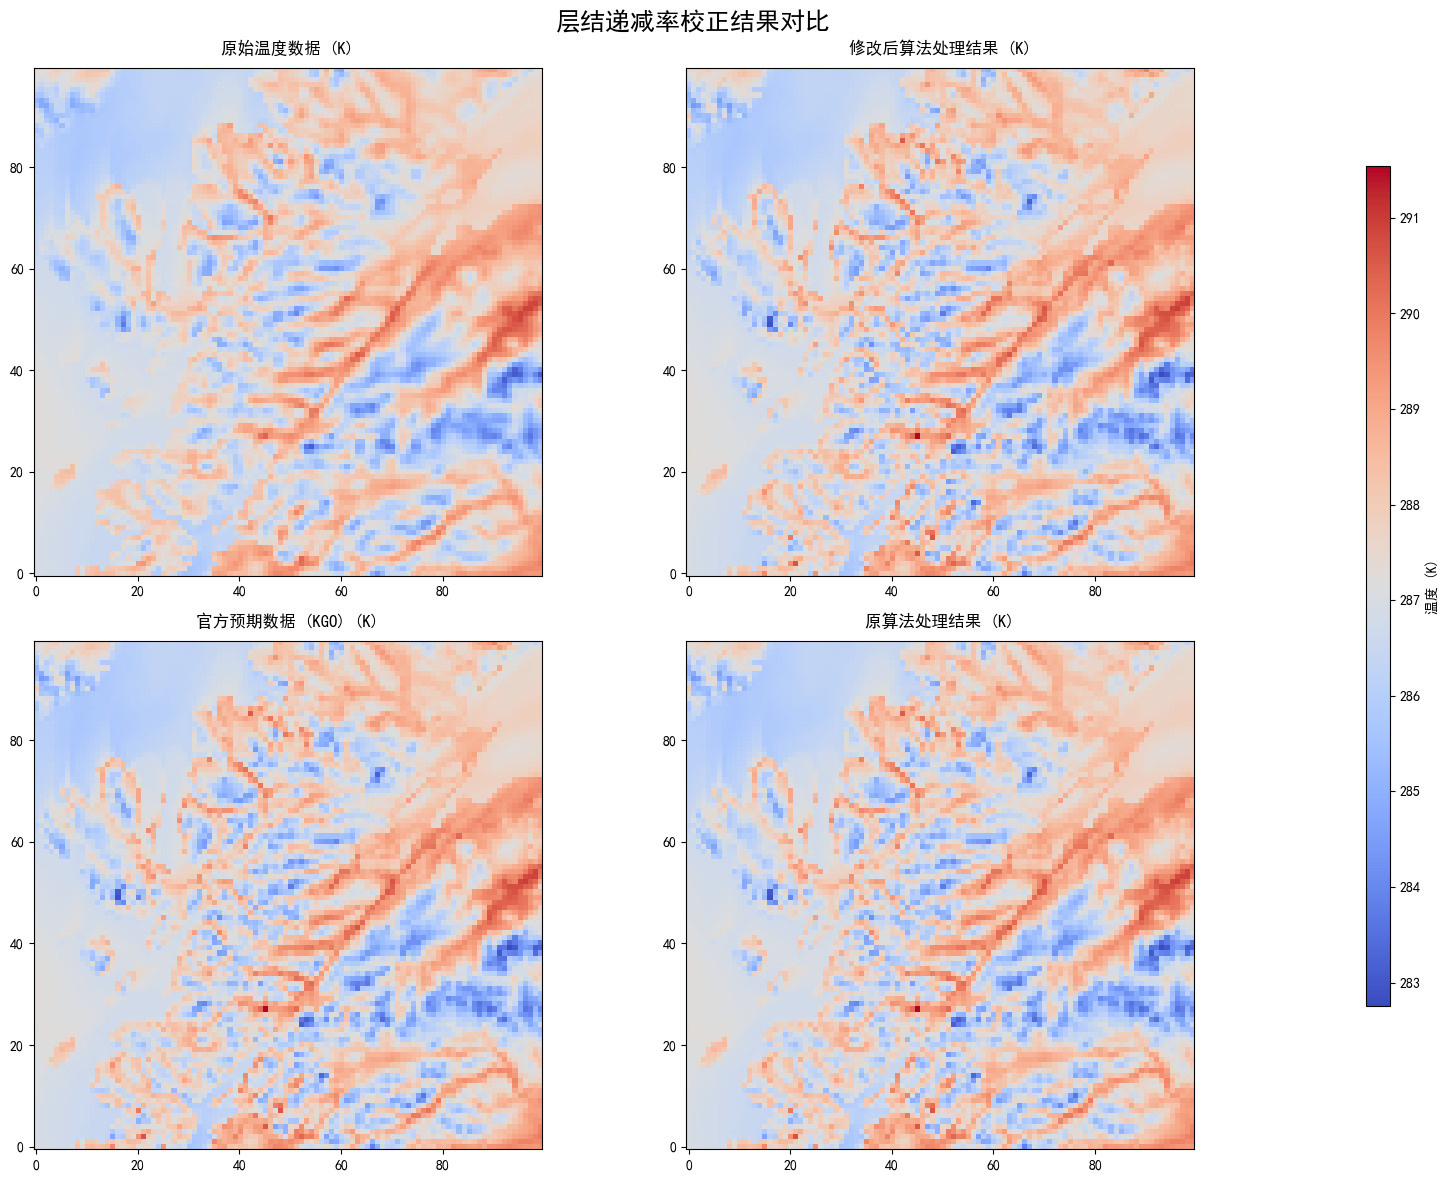


=== 统计对比 ===
原始温度平均值: 287.24 K
修改后算法平均值: 287.26 K
官方预期平均值: 287.26 K
原算法平均值: 287.26 K

=== 与官方预期的差异 ===
修改后算法 vs 官方预期 - 平均绝对误差: 0.0000 K
原算法 vs 官方预期 - 平均绝对误差: 0.0000 K


In [8]:
print("正在生成四幅对比图...")

# ========== 统一颜色范围 ==========
all_temp_data = [
    temperature_data_aligned.values,
    processed_temperature_new,
    official_expected_grid,
    processed_temperature_original
]
vmin = min(d.min() for d in all_temp_data)
vmax = max(d.max() for d in all_temp_data)

# ========== 调整画布大小和布局 ==========
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('层结递减率校正结果对比', fontsize=18, y=0.98)

# 1. 原始温度数据（统一 vmin/vmax）
im1 = axes[0, 0].imshow(temperature_data_aligned.values, cmap='coolwarm', 
                        origin='lower', vmin=vmin, vmax=vmax)
axes[0, 0].set_title('原始温度数据 (K)', fontsize=12, pad=10)

# 2. 修改后的算法处理结果
im2 = axes[0, 1].imshow(processed_temperature_new, cmap='coolwarm', 
                        origin='lower', vmin=vmin, vmax=vmax)
axes[0, 1].set_title('修改后算法处理结果 (K)', fontsize=12, pad=10)

# 3. 官方预期数据 (KGO)
im3 = axes[1, 0].imshow(official_expected_grid, cmap='coolwarm', 
                        origin='lower', vmin=vmin, vmax=vmax)
axes[1, 0].set_title('官方预期数据 (KGO) (K)', fontsize=12, pad=10)

# 4. 原算法处理结果
im4 = axes[1, 1].imshow(processed_temperature_original, cmap='coolwarm', 
                        origin='lower', vmin=vmin, vmax=vmax)
axes[1, 1].set_title('原算法处理结果 (K)', fontsize=12, pad=10)

# ========== 调整布局，右侧留空间给 colorbar ==========
plt.tight_layout(rect=[0, 0, 0.9, 1])  # 右侧留 10% 空间

# 添加统一 colorbar（细长的，放右侧）
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im4, cax=cbar_ax, label='温度 (K)')

plt.show()

# 输出统计信息
print(f"\n=== 统计对比 ===")
print(f"原始温度平均值: {temperature_data_aligned.values.mean():.2f} K")
print(f"修改后算法平均值: {processed_temperature_new.mean():.2f} K")
print(f"官方预期平均值: {official_expected_grid.mean():.2f} K")
print(f"原算法平均值: {processed_temperature_original.mean():.2f} K")

# 计算差异
diff_new_official = processed_temperature_new - official_expected_grid
diff_original_official = processed_temperature_original - official_expected_grid

print(f"\n=== 与官方预期的差异 ===")
print(f"修改后算法 vs 官方预期 - 平均绝对误差: {np.abs(diff_new_official).mean():.4f} K")
print(f"原算法 vs 官方预期 - 平均绝对误差: {np.abs(diff_original_official).mean():.4f} K")

## CLI使用说明

在终端（PowerShell）执行以下命令，即可调用 CLI 示例脚本生成对比文件：
`temperature/test_data/apply_lapse_rate_data/normalized_meb6d/cli_apply_lapse_rate_result.nc`

```powershell
python -m temperature.cli.anc_lapse_rate
```

脚本底部已配置官方测试数据路径与 `output_path`；如需自定义，请修改 `temperature/cli/anc_lapse_rate.py` 中 `if __name__ == "__main__"` 段，或在 Notebook 中调用 `process()`。

执行完命令后，继续运行下一个单元做图形对比与误差统计。


CLI vs plugin MAE: 0.00024994 K
CLI vs ORIG_CLI MAE: 0.00024994 K
CLI vs plugin max abs diff: 0.00052930 K
CLI vs ORIG_CLI max abs diff: 0.00052930 K


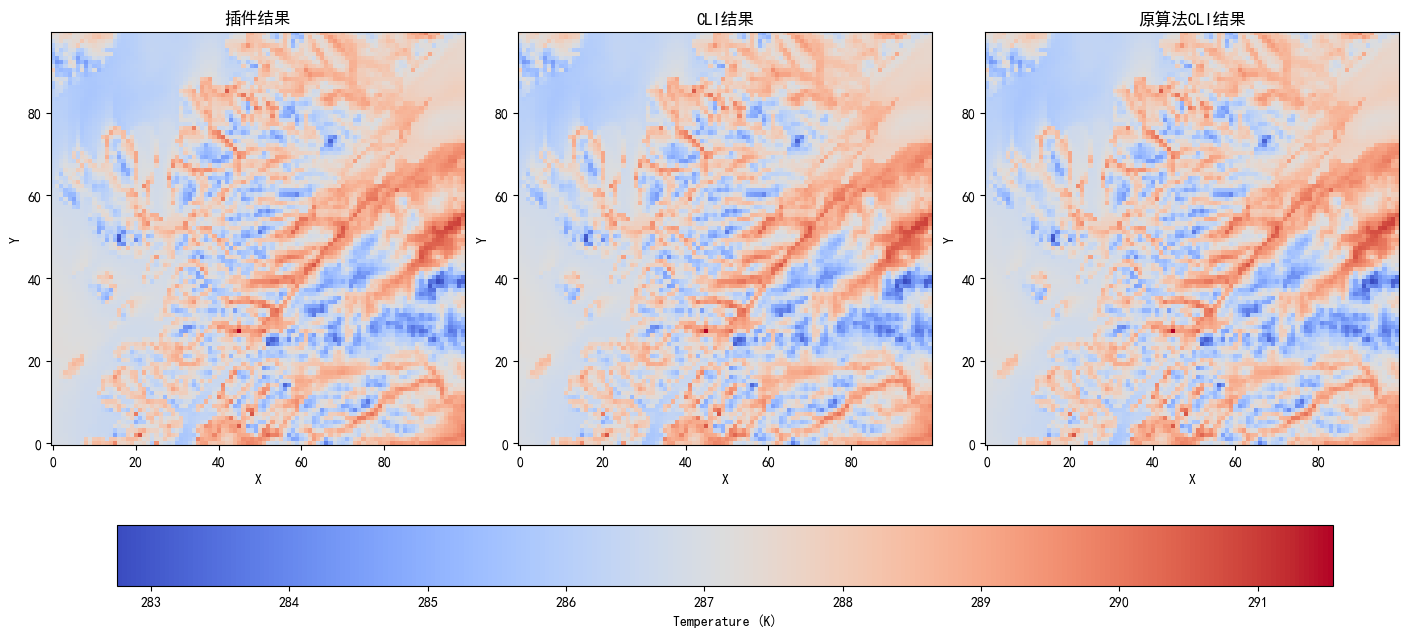

In [9]:
# CLI output verification and plotting
from pathlib import Path

cli_output_path = Path('../test_data/apply_lapse_rate_data/normalized_meb6d/cli_apply_lapse_rate_result.nc').resolve()
original_cli_lapse_path = Path('../test_data/apply_lapse_rate_data/normalized_meb6d/original_cli_result.nc').resolve()
if not original_cli_lapse_path.exists():
    original_cli_lapse_path = Path('../test_data/apply_lapse_rate_data/original_cli_result.nc').resolve()

if not cli_output_path.exists():
    raise FileNotFoundError(f"CLI output file not found: {cli_output_path}")
if not original_cli_lapse_path.exists():
    raise FileNotFoundError(f"Original CLI output file not found: {original_cli_lapse_path}")

cli_ds = xr.open_dataset(cli_output_path)
if "air_temperature" in cli_ds.data_vars:
    cli_values = cli_ds["air_temperature"].values
else:
    first_var = list(cli_ds.data_vars)[0]
    cli_values = cli_ds[first_var].values

orig_cli_ds = xr.open_dataset(original_cli_lapse_path, decode_timedelta=True)
if "air_temperature" in orig_cli_ds.data_vars:
    orig_cli_values = orig_cli_ds["air_temperature"].values
else:
    first_var = list(orig_cli_ds.data_vars)[0]
    orig_cli_values = orig_cli_ds[first_var].values


cli_values_2d = np.asarray(cli_values).squeeze()
plugin_values_2d = np.asarray(processed_temperature_new).squeeze()
orig_cli_values_2d = np.asarray(orig_cli_values).squeeze()

cli_mae = np.mean(np.abs(cli_values_2d - plugin_values_2d))
mae_cli_orig_cli = np.mean(np.abs(cli_values_2d - orig_cli_values_2d))
cli_max_abs = np.max(np.abs(cli_values_2d - plugin_values_2d))
orig_cli_max_abs = np.max(np.abs(cli_values_2d - orig_cli_values_2d))
print(f"CLI vs plugin MAE: {cli_mae:.8f} K")
print(f"CLI vs ORIG_CLI MAE: {mae_cli_orig_cli:.8f} K")
print(f"CLI vs plugin max abs diff: {cli_max_abs:.8f} K")
print(f"CLI vs ORIG_CLI max abs diff: {orig_cli_max_abs:.8f} K")

vmin = min(plugin_values_2d.min(), cli_values_2d.min(),orig_cli_values_2d.min())
vmax = max(plugin_values_2d.max(), cli_values_2d.max(),orig_cli_values_2d.max())

fig, axes = plt.subplots(1, 3, figsize=(14, 6), constrained_layout=True)
im0 = axes[0].imshow(plugin_values_2d, cmap="coolwarm", origin="lower", vmin=vmin, vmax=vmax)
axes[0].set_title("插件结果")

im1 = axes[1].imshow(cli_values_2d, cmap="coolwarm", origin="lower", vmin=vmin, vmax=vmax)
axes[1].set_title("CLI结果")

im1 = axes[2].imshow(cli_values_2d, cmap="coolwarm", origin="lower", vmin=vmin, vmax=vmax)
axes[2].set_title("原算法CLI结果")

for ax in axes:
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

# 统一色标放在底部，避免遮挡图像
cb_temp = fig.colorbar(im1, ax=axes, location="bottom", shrink=0.9, pad=0.08)
cb_temp.set_label("Temperature (K)")

plt.show()


# LapseRate 算法验证

本部分使用官方测试数据验证修改后的 LapseRate 算法。通过对比修改后算法、官方预期结果 (KGO) 和原算法的处理结果，确保算法实现的正确性。

**注意：** 与 ApplyGriddedLapseRate 部分不同，此处不再显示原始温度数据图，仅关注层结递减率计算结果的对比。

In [10]:
from temperature.src.lapse_rate import LapseRate

## 数据预处理

In [11]:
temp_lapse_dir = Path('../test_data/temp_lapse_rate_data').resolve()
temp_lapse_norm_dir = temp_lapse_dir / 'normalized_meb6d'
temp_lapse_norm_dir.mkdir(parents=True, exist_ok=True)
RUN_TEMP_LAPSE_PREPROCESS = False # 设为 True 时执行预处理

temp_lapse_preprocess_inputs = [
    ('temperature_at_screen_level.nc', 'air_temperature'),
    ('ukvx_orography.nc', 'surface_altitude'),
    ('ukvx_landmask.nc', 'land_binary_mask'),
    ('kgo.nc', 'air_temperature_lapse_rate'),
    ('original_lapse_rate_result.nc', 'air_temperature_lapse_rate'),
]

if RUN_TEMP_LAPSE_PREPROCESS:
    for filename, var_name in temp_lapse_preprocess_inputs:
        input_path = temp_lapse_dir / filename
        output_path = temp_lapse_norm_dir / filename
        print(f'正在处理: {filename}')
        preprocess_to_meb6d(input_path, output_path, var_name)

def open_preferred_lapse(filename: str) -> xr.Dataset:
    norm_path = temp_lapse_norm_dir / filename
    raw_path = temp_lapse_dir / filename
    target = norm_path if norm_path.exists() else raw_path
    print(f'读取: {target}')
    return xr.open_dataset(target)

## 读取输入数据

In [12]:
# 读取温度数据
temp_lapse_ds = open_preferred_lapse('temperature_at_screen_level.nc')
temperature_lapse_data = temp_lapse_ds['air_temperature']

# 读取地形数据
orog_lapse_ds = open_preferred_lapse('ukvx_orography.nc')
orog_lapse_data = orog_lapse_ds['surface_altitude']

# 读取陆地掩膜数据
landmask_lapse_ds = open_preferred_lapse('ukvx_landmask.nc')
landmask_lapse_data = landmask_lapse_ds['land_binary_mask']

# 统一对齐坐标结构 - 使用温度数据的坐标作为基准
lat_coords_lapse = temperature_lapse_data['lat'].values if 'lat' in temperature_lapse_data.coords else temp_lapse_ds['projection_y_coordinate'].values
lon_coords_lapse = temperature_lapse_data['lon'].values if 'lon' in temperature_lapse_data.coords else temp_lapse_ds['projection_x_coordinate'].values

# 重新构建所有数据数组，使用统一的坐标和正确的属性
temperature_lapse_aligned = xr.DataArray(
    temperature_lapse_data.squeeze(drop=True).values,
    dims=['projection_y_coordinate', 'projection_x_coordinate'],
    coords={'projection_y_coordinate': lat_coords_lapse, 'projection_x_coordinate': lon_coords_lapse},
    attrs={'units': 'K'}
)

orog_lapse_aligned = xr.DataArray(
    orog_lapse_data.squeeze(drop=True).values,
    dims=['projection_y_coordinate', 'projection_x_coordinate'],
    coords={'projection_y_coordinate': lat_coords_lapse, 'projection_x_coordinate': lon_coords_lapse},
    attrs={'units': 'm'}
)

landmask_lapse_aligned = xr.DataArray(
    landmask_lapse_data.squeeze(drop=True).values,
    dims=['projection_y_coordinate', 'projection_x_coordinate'],
    coords={'projection_y_coordinate': lat_coords_lapse, 'projection_x_coordinate': lon_coords_lapse},
    attrs={'units': '1'}
)

# 读取官方预期数据 (KGO)
kgo_lapse_ds = open_preferred_lapse('kgo.nc')
kgo_lapse_rate = kgo_lapse_ds['air_temperature_lapse_rate'].squeeze(drop=True)

# 读取原算法处理结果
original_lapse_result_ds = open_preferred_lapse('original_lapse_rate_result.nc')
original_lapse_rate = original_lapse_result_ds['air_temperature_lapse_rate'].squeeze(drop=True).values

print(f"温度数据形状: {temperature_lapse_aligned.shape}")
print(f"地形数据形状: {orog_lapse_aligned.shape}")
print(f"陆地掩膜形状: {landmask_lapse_aligned.shape}")
print(f"官方预期数据形状: {kgo_lapse_rate.shape}")
print(f"原算法结果形状: {original_lapse_rate.shape}")

读取: D:\workspace\improver\temperature\test_data\temp_lapse_rate_data\normalized_meb6d\temperature_at_screen_level.nc
读取: D:\workspace\improver\temperature\test_data\temp_lapse_rate_data\normalized_meb6d\ukvx_orography.nc
读取: D:\workspace\improver\temperature\test_data\temp_lapse_rate_data\normalized_meb6d\ukvx_landmask.nc
读取: D:\workspace\improver\temperature\test_data\temp_lapse_rate_data\normalized_meb6d\kgo.nc
读取: D:\workspace\improver\temperature\test_data\temp_lapse_rate_data\normalized_meb6d\original_lapse_rate_result.nc
温度数据形状: (120, 110)
地形数据形状: (120, 110)
陆地掩膜形状: (120, 110)
官方预期数据形状: (120, 110)
原算法结果形状: (120, 110)


## LapseRate算法调用

In [13]:
# 调用修改后的LapseRate算法
plugin_lapse = LapseRate()
modified_lapse_rate = plugin_lapse(
    temperature_lapse_data,
    orog_lapse_data,
    landmask_lapse_data
)
modified_lapse_rate = np.asarray(modified_lapse_rate).squeeze()

print(f"修改后算法处理完成！层结递减率范围: [{modified_lapse_rate.min():.6f}, {modified_lapse_rate.max():.6f}] K/m")
print(f"官方预期数据范围: [{kgo_lapse_rate.values.min():.6f}, {kgo_lapse_rate.values.max():.6f}] K/m")
print(f"原算法处理结果范围: [{original_lapse_rate.min():.6f}, {original_lapse_rate.max():.6f}] K/m")

修改后算法处理完成！层结递减率范围: [-0.009800, 0.029400] K/m
官方预期数据范围: [-0.009800, 0.029400] K/m
原算法处理结果范围: [-0.009800, 0.029400] K/m


## 结果对比

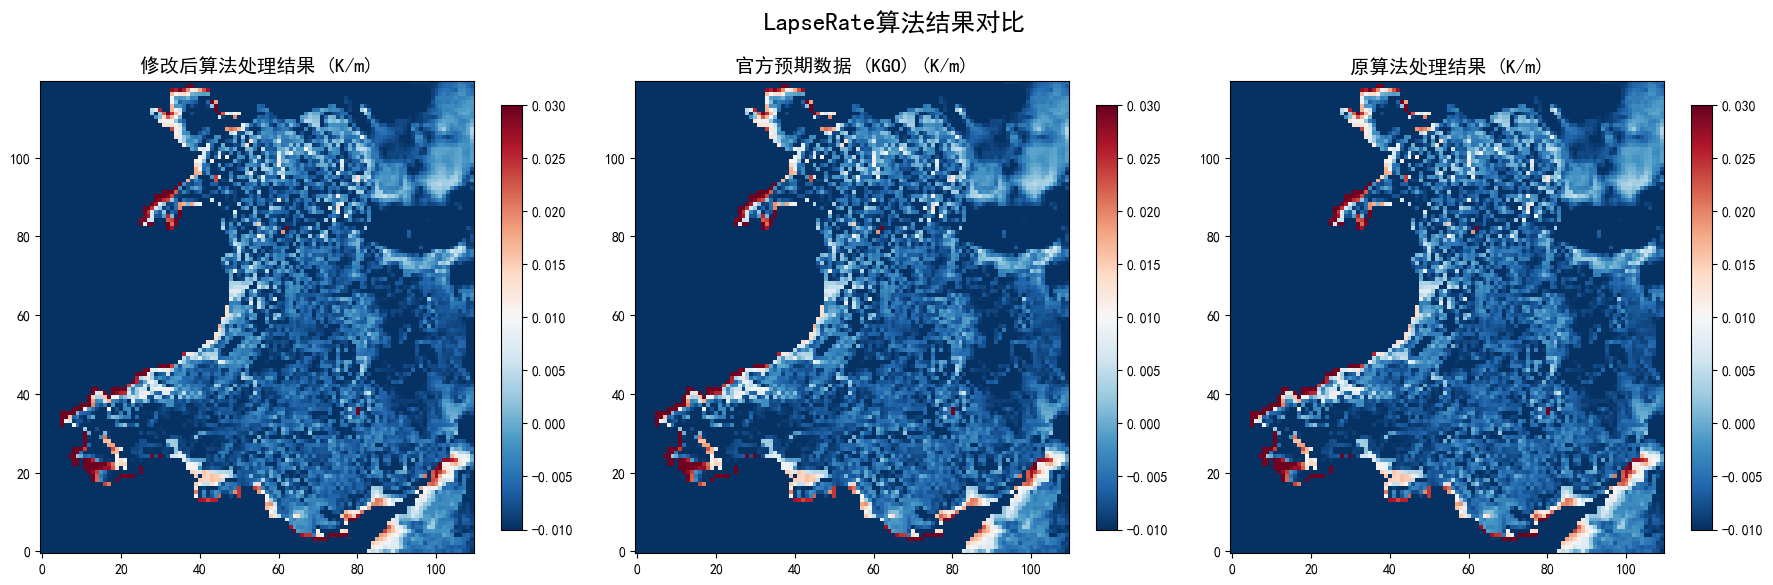


=== LapseRate统计对比 ===
修改后算法平均值: -0.006459 K/m
官方预期平均值: -0.006459 K/m
原算法平均值: -0.006459 K/m

=== 与官方预期的差异 ===
修改后算法 vs 官方预期 - 平均绝对误差: 0.000000 K/m
原算法 vs 官方预期 - 平均绝对误差: 0.000000 K/m


In [14]:
# 创建LapseRate三幅对比图（移除原始温度数据图）
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('LapseRate算法结果对比', fontsize=18)

# 1. 修改后的算法处理结果
im1 = axes[0].imshow(modified_lapse_rate, cmap='RdBu_r', origin='lower', vmin=-0.01, vmax=0.03)
axes[0].set_title('修改后算法处理结果 (K/m)', fontsize=14)
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# 2. 官方预期数据 (KGO)
im2 = axes[1].imshow(kgo_lapse_rate.values, cmap='RdBu_r', origin='lower', vmin=-0.01, vmax=0.03)
axes[1].set_title('官方预期数据 (KGO) (K/m)', fontsize=14)
plt.colorbar(im2, ax=axes[1], shrink=0.8)

# 3. 原算法处理结果
im3 = axes[2].imshow(original_lapse_rate, cmap='RdBu_r', origin='lower', vmin=-0.01, vmax=0.03)
axes[2].set_title('原算法处理结果 (K/m)', fontsize=14)
plt.colorbar(im3, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.show()

# 输出统计信息
print(f"\n=== LapseRate统计对比 ===")
print(f"修改后算法平均值: {modified_lapse_rate.mean():.6f} K/m")
print(f"官方预期平均值: {kgo_lapse_rate.values.mean():.6f} K/m")
print(f"原算法平均值: {original_lapse_rate.mean():.6f} K/m")

# 计算差异
diff_modified_kgo = modified_lapse_rate - kgo_lapse_rate.values
diff_original_kgo = original_lapse_rate - kgo_lapse_rate.values

print(f"\n=== 与官方预期的差异 ===")
print(f"修改后算法 vs 官方预期 - 平均绝对误差: {np.abs(diff_modified_kgo).mean():.6f} K/m")
print(f"原算法 vs 官方预期 - 平均绝对误差: {np.abs(diff_original_kgo).mean():.6f} K/m")

## LapseRate CLI 内存对比

在下方单元格中直接调用 `temperature/cli/dsc_temp_lapse_rate.py` 的 `process()`，并设置 `output_path=None`，在内存中获得修改后 CLI 结果，避免 `meb.write_griddata_to_nc` 写盘时的 NetCDF 量化误差（`scale_factor=0.001`）干扰对比。

对比对象：

- **修改后 CLI**：`process(..., output_path=None)` 返回值
- **官方预期 (KGO)**：前文已读取的 `kgo_lapse_rate`
- **原算法 CLI 参考**：测试数据中的 `original_cli_result.nc`（只读参考文件）

路径与算法参数与 `dsc_temp_lapse_rate.py` 底部 `__main__` 段一致。


修改后 CLI vs KGO MAE: 0.00000000 K/m
修改后 CLI vs 原算法 CLI MAE: 0.00000000 K/m


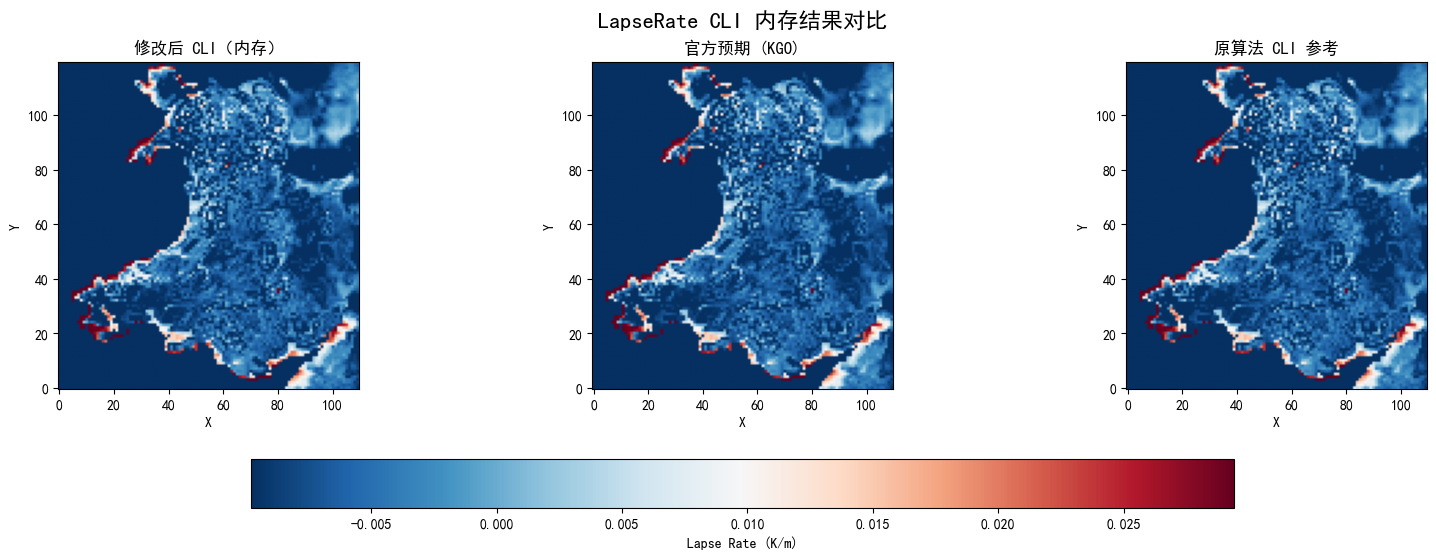

In [15]:
from temperature.cli.dsc_temp_lapse_rate import process

_cli_temperature_path = str(temp_lapse_norm_dir / "temperature_at_screen_level.nc")
_cli_orography_path = str(temp_lapse_norm_dir / "ukvx_orography.nc")
_cli_land_sea_mask_path = str(temp_lapse_norm_dir / "ukvx_landmask.nc")

#调用CLI应用函数
cli_lapse_result = process(
    _cli_temperature_path,
    orography_path=_cli_orography_path,
    land_sea_mask_path=_cli_land_sea_mask_path,
    output_path=None,
)
cli_lapse_values = np.asarray(cli_lapse_result.values, dtype=np.float32).squeeze()
kgo_values = np.asarray(kgo_lapse_rate.values, dtype=np.float32).squeeze()

original_cli_lapse_path = temp_lapse_norm_dir / "original_cli_result.nc"
if not original_cli_lapse_path.exists():
    original_cli_lapse_path = temp_lapse_dir / "original_cli_result.nc"
if not original_cli_lapse_path.exists():
    raise FileNotFoundError(f"未找到原算法 CLI 参考文件: {original_cli_lapse_path}")

with xr.open_dataset(original_cli_lapse_path, decode_timedelta=False) as orig_cli_ds:
    if "air_temperature_lapse_rate" in orig_cli_ds.data_vars:
        orig_cli_lapse_values = orig_cli_ds["air_temperature_lapse_rate"].values
    else:
        first_var = next(iter(orig_cli_ds.data_vars))
        orig_cli_lapse_values = orig_cli_ds[first_var].values
orig_cli_lapse_values = np.asarray(orig_cli_lapse_values, dtype=np.float32).squeeze()

mae_cli_kgo = float(np.mean(np.abs(cli_lapse_values - kgo_values)))
mae_cli_orig_cli = float(np.mean(np.abs(cli_lapse_values - orig_cli_lapse_values)))

print(f"修改后 CLI vs KGO MAE: {mae_cli_kgo:.8f} K/m")
print(f"修改后 CLI vs 原算法 CLI MAE: {mae_cli_orig_cli:.8f} K/m")

all_vals = [cli_lapse_values, kgo_values, orig_cli_lapse_values]
vmin = min(v.min() for v in all_vals)
vmax = max(v.max() for v in all_vals)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), constrained_layout=True)
fig.suptitle("LapseRate CLI 内存结果对比", fontsize=16)

im0 = axes[0].imshow(cli_lapse_values, cmap="RdBu_r", origin="lower", vmin=vmin, vmax=vmax)
axes[0].set_title("修改后 CLI（内存）")
im1 = axes[1].imshow(kgo_values, cmap="RdBu_r", origin="lower", vmin=vmin, vmax=vmax)
axes[1].set_title("官方预期 (KGO)")
im2 = axes[2].imshow(orig_cli_lapse_values, cmap="RdBu_r", origin="lower", vmin=vmin, vmax=vmax)
axes[2].set_title("原算法 CLI 参考")

for ax in axes:
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

cb_main = fig.colorbar(im2, ax=axes, location="bottom", shrink=0.9, pad=0.08)
cb_main.set_label("Lapse Rate (K/m)")

plt.show()